# Урок 1. Введение: что такое градиентный бустинг

**Интерактивная версия:** `lessons/lesson_1/web/index.html`

В этом ноутбуке:
1. «Бустинг одного числа» — самая маленькая модель, на которой видна вся идея.
2. Бустинг на деревьях шаг за шагом: как ступеньки облегают данные.
3. Первая модель в scikit-learn и её точная копия из учебной библиотеки `gbcourse`.

In [1]:
# Подключаем учебную библиотеку курса gbcourse (папка shared/python в корне курса)
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import numpy as np
import matplotlib.pyplot as plt
from gbcourse import datasets, GBRegressor
from gbcourse.plotting import use_course_style, plot_data, plot_truth, plot_predict_1d, plot_stages, plot_boosting_step

use_course_style()

## 1. Бустинг одного числа

Модель — одно число $F$. Цель — $y = 10$. На каждом шаге «слабый ученик» сообщает остаток
$r = y - F$, а мы прибавляем лишь его долю $\nu$ (темп обучения):

$$F_m = F_{m-1} + \nu \, (y - F_{m-1}).$$

Остаток умножается на $(1-\nu)$ за шаг: $r_m = (1-\nu)^m \, r_0$.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


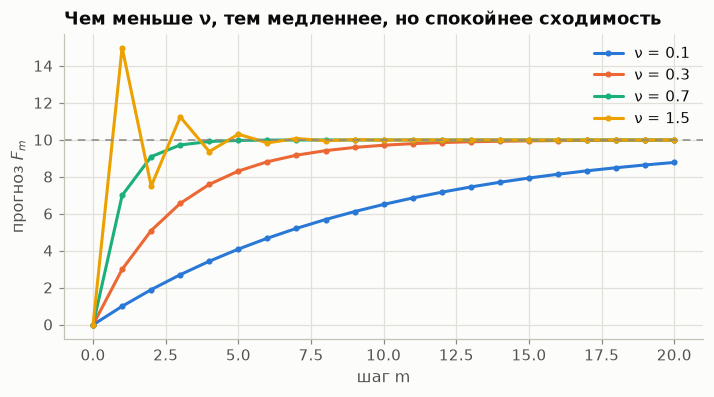

In [2]:
def boost_a_number(y: float, nu: float, steps: int) -> np.ndarray:
    F = [0.0]
    for _ in range(steps):
        r = y - F[-1]          # остаток: сколько осталось до цели
        F.append(F[-1] + nu * r)
    return np.array(F)


fig, ax = plt.subplots(figsize=(7.5, 3.6))
for nu in [0.1, 0.3, 0.7, 1.5]:
    ax.plot(boost_a_number(10, nu, 20), marker="o", ms=3, label=f"ν = {nu}")
ax.axhline(10, color="#898781", lw=1, ls=(0, (5, 4)))
ax.set_xlabel("шаг m")
ax.set_ylabel("прогноз $F_m$")
ax.set_title("Чем меньше ν, тем медленнее, но спокойнее сходимость")
ax.legend()
plt.show()

При $\nu = 1.5$ прогноз перелетает цель, но колебания затухают, так как $|1 - \nu| = 0.5 < 1$.
При $\nu > 2$ они бы росли. Запомните этот образ: в настоящем бустинге темп обучения ведёт себя так же.

## 2. Бустинг на деревьях шаг за шагом

Данные — «волна с трендом»: $y = \sin x + 0.3x + \varepsilon$. Модель начинает со среднего,
а каждое дерево глубины 2 приближает текущие остатки.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


F0 = среднее y = 1.5555  (проверка: 1.5555)


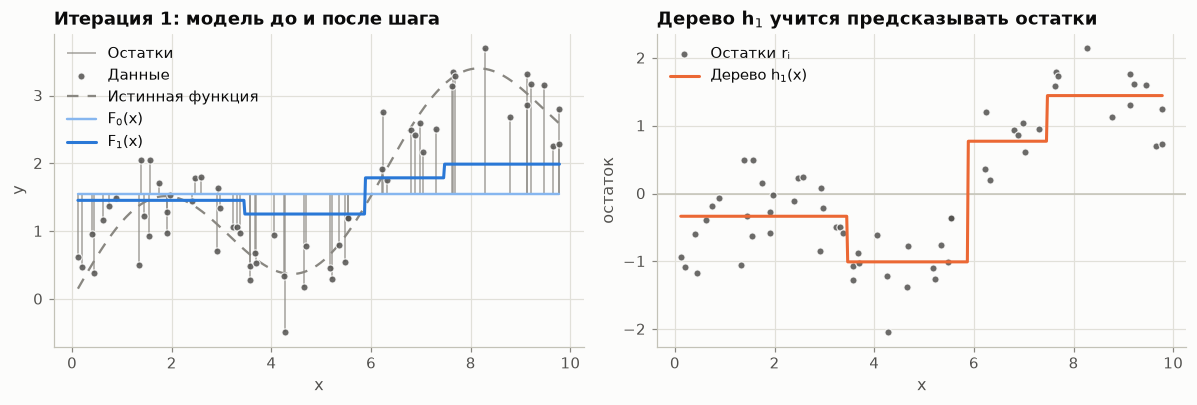

In [3]:
X, y = datasets.regression_1d(kind="wave", n=60, noise=0.35, seed=7)
model = GBRegressor(n_estimators=60, learning_rate=0.3, max_depth=2).fit(X, y)

print(f"F0 = среднее y = {model.init_:.4f}  (проверка: {y.mean():.4f})")
plot_boosting_step(model, X, y, m=1, truth_kind="wave")
plt.tight_layout()
plt.show()

Слева — модель до и после первого шага. Справа — остатки константы $F_0$ и первое дерево,
которое их приближает. Модель после шага: $F_1 = F_0 + 0.3 \cdot h_1$.

Посмотрим, как выглядит модель после разного числа деревьев:

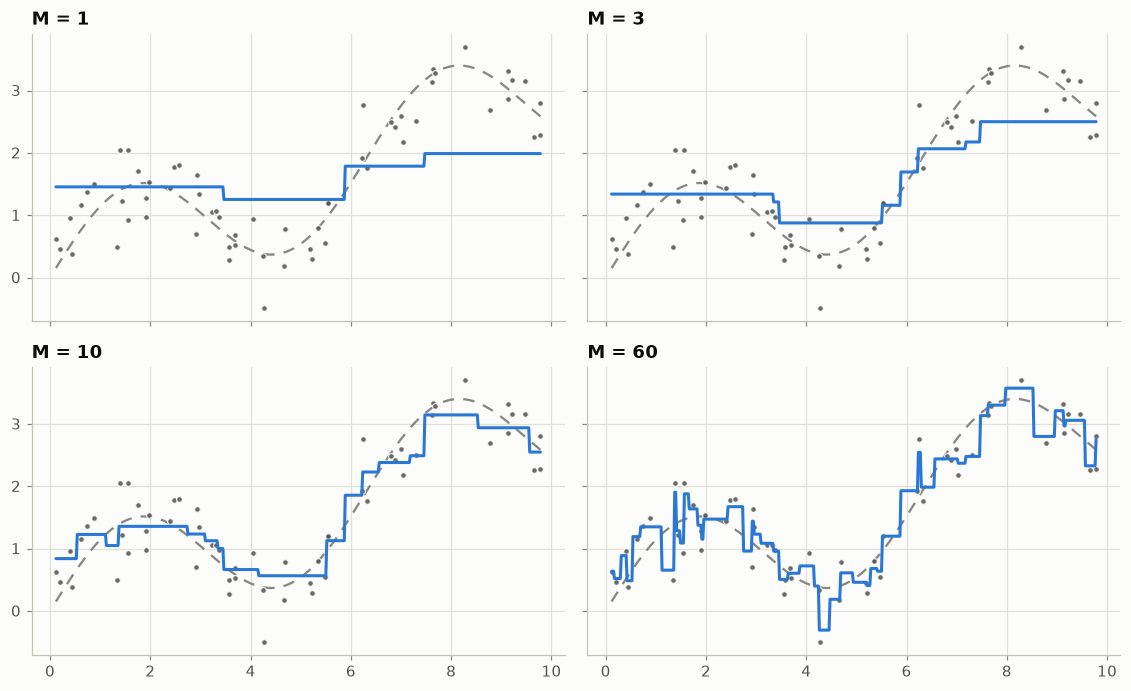

In [4]:
plot_stages(model, X, y, stages=(1, 3, 10, 60), truth_kind="wave")
plt.show()

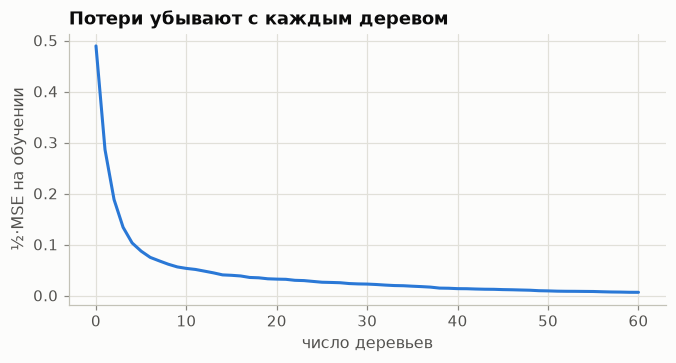

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(model.history_["train"], color="#2a78d6")
ax.set_xlabel("число деревьев")
ax.set_ylabel("½·MSE на обучении")
ax.set_title("Потери убывают с каждым деревом")
plt.show()

## 3. Первая модель в scikit-learn — и её копия в gbcourse

In [6]:
from sklearn.ensemble import GradientBoostingRegressor

sk = GradientBoostingRegressor(n_estimators=60, learning_rate=0.3, max_depth=2).fit(X, y)
print("Прогноз sklearn в x = 5:  ", sk.predict([[5.0]])[0])
print("Прогноз gbcourse в x = 5: ", model.predict(np.array([[5.0]]))[0])
print("Максимальное расхождение на обучении:", np.abs(sk.predict(X) - model.predict(X)).max())

Прогноз sklearn в x = 5:   0.46010236105134666
Прогноз gbcourse в x = 5:  0.46010236105134666
Максимальное расхождение на обучении: 0.0


Расхождение порядка $10^{-15}$ — это погрешность округления чисел с плавающей точкой.
Учебная реализация делает ровно то же, что scikit-learn, но её код открыт и разобран в курсе:
`shared/python/gbcourse/boosting.py`.

## Упражнения

1. Найдите минимальное число шагов, за которое «бустинг одного числа» с $\nu = 0.1$ подойдёт к цели ближе чем на 1%.
   Проверьте ответ формулой $(1-\nu)^m < 0.01$.
2. Обучите `GBRegressor` на тех же данных с `max_depth=1` и `learning_rate=0.3`. Сколько деревьев нужно,
   чтобы потери на обучении стали меньше, чем у модели с `max_depth=2` после 20 деревьев?
3. Постройте `plot_stages` для `learning_rate=1.0`. Чем отличаются кривые?

<details><summary>Решения</summary>

Запускаемые решения: `python lessons/lesson_1/exercises/solutions.py`.
</details>